11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước x_train: (60000, 28, 28)
Kích thước y_train: (60000,)
Kích thước x_test : (10000, 28, 28)
Kích thước y_test : (10000,)
Sau khi pad, x_train: (60000, 32, 32, 1)
Sau khi pad, x_test : (10000, 32, 32, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.8893 - loss: 0.3784 - val_accuracy: 0.9622 - val_loss: 0.1323
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.9594 - loss: 0.1331 - val_accuracy: 0.9760 - val_loss: 0.0827
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.9745 - loss: 0.0848 - val_accuracy: 0.9812 - val_loss: 0.0660
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9823 - val_loss: 0.0574
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.9852 - loss: 0.0480 - val_accuracy: 0.9842 - val_loss: 0.0540

Độ chính xác trên tập test: 0.9832
Hàm mất mát trên tập test: 0.0538

Nhãn thật      : 7
Nhãn dự đoán   : 7
Độ tin cậy     : 0.9997


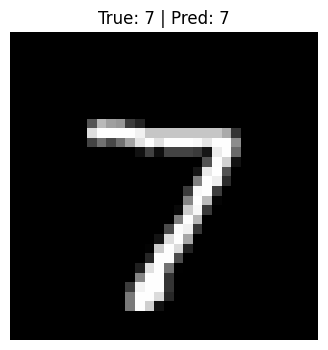

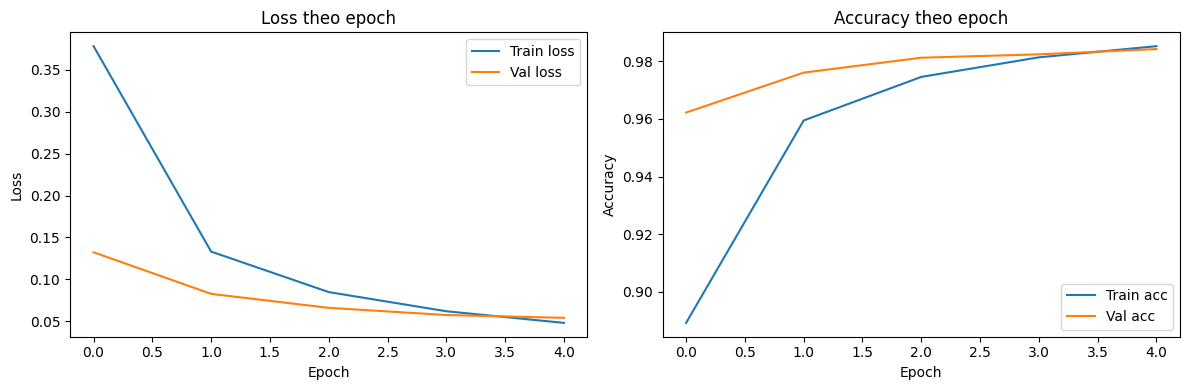

Kiểm tra hoàn tất: dữ liệu, mô hình và dự đoán có định dạng hợp lệ.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Xây dựng, huấn luyện và kiểm tra mạng LeNet-5 với MNIST
# Chương/Mục liên quan: Chương 7 - Mạng nơ-ron tích chập cho phân loại ảnh
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa quá trình xây dựng và huấn luyện mạng LeNet-5 cho bài toán phân loại chữ số viết tay.
# - Giúp người học quan sát trực tiếp vai trò của các lớp convolution, pooling và fully-connected.
# - Liên hệ phần code với kiến trúc CNN cổ điển trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Hiểu được cách dữ liệu ảnh được chuẩn hóa và đưa vào mạng CNN.
# 2. Quan sát được quá trình học thông qua loss và accuracy.
# 3. Biết kiểm tra kết quả dự đoán của mô hình trên ảnh kiểm thử.

# Input:
# - Dữ liệu đầu vào: bộ MNIST có sẵn trong tensorflow.keras.datasets
# - Kiểu dữ liệu: ảnh mức xám kích thước 28x28, được pad thành 32x32x1

# Output:
# - Kích thước dữ liệu train/test
# - Kiến trúc mạng LeNet-5
# - Độ chính xác và hàm mất mát trên tập test
# - Ảnh kiểm thử cùng nhãn thật và nhãn dự đoán
# - Đường học loss và accuracy theo epoch

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa kiến trúc LeNet-5;
# - Các bước xử lý tương ứng với pipeline huấn luyện CNN;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical


# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Kích thước x_train:", x_train.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước x_test :", x_test.shape)
print("Kích thước y_test :", y_test.shape)


# ============================================================
# 3. HIỂN THỊ VÀ TIỀN XỬ LÝ DỮ LIỆU ĐẦU VÀO
# ============================================================

# Chuẩn hóa ảnh về miền giá trị [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Thêm chiều kênh: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

# Pad ảnh từ 28x28 thành 32x32 để phù hợp với đầu vào LeNet-5 gốc
x_train = np.pad(x_train, ((0, 0), (2, 2), (2, 2), (0, 0)), mode="constant")
x_test  = np.pad(x_test,  ((0, 0), (2, 2), (2, 2), (0, 0)), mode="constant")

print("Sau khi pad, x_train:", x_train.shape)
print("Sau khi pad, x_test :", x_test.shape)

# Mã hóa one-hot cho nhãn phân loại 10 lớp
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)


# ============================================================
# 4. XỬ LÝ CHÍNH: XÂY DỰNG VÀ HUẤN LUYỆN LENET-5
# ============================================================

# Kiến trúc LeNet-5:
# Input: 32x32x1
# C1: Conv 5x5, 6 feature maps, tanh      -> 28x28x6
# S2: Average Pooling 2x2, stride 2       -> 14x14x6
# C3: Conv 5x5, 16 feature maps, tanh     -> 10x10x16
# S4: Average Pooling 2x2, stride 2       -> 5x5x16
# C5: Conv 5x5, 120 feature maps, tanh    -> 1x1x120
# F6: Dense 84, tanh
# Output: Dense 10, softmax

model = models.Sequential([
    layers.Input(shape=(32, 32, 1)),

    layers.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(filters=120, kernel_size=(5, 5), activation='tanh'),

    layers.Flatten(),
    layers.Dense(84, activation='tanh'),

    # LeNet-5 gốc dùng cơ chế phân lớp khác;
    # trong thực hành hiện nay thường dùng softmax cho phân loại đa lớp.
    layers.Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)


# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"\nĐộ chính xác trên tập test: {test_acc:.4f}")
print(f"Hàm mất mát trên tập test: {test_loss:.4f}")

idx = 0
sample_image = x_test[idx]
sample_label = y_test[idx]

pred = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)
pred_class = np.argmax(pred)
pred_prob = np.max(pred)

print(f"\nNhãn thật      : {sample_label}")
print(f"Nhãn dự đoán   : {pred_class}")
print(f"Độ tin cậy     : {pred_prob:.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"True: {sample_label} | Pred: {pred_class}")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss theo epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy theo epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

assert x_train.shape[1:] == (32, 32, 1)
assert x_test.shape[1:] == (32, 32, 1)
assert y_train_cat.shape[1] == 10
assert y_test_cat.shape[1] == 10
assert pred.shape == (1, 10)
assert 0 <= pred_class <= 9

print("Kiểm tra hoàn tất: dữ liệu, mô hình và dự đoán có định dạng hợp lệ.")


# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi epochs từ 5 lên 10 để quan sát đường học loss và accuracy.
# 2. Thay đổi batch_size từ 128 sang 64 hoặc 256 để quan sát ảnh hưởng đến quá trình huấn luyện.
# 3. Thay đổi idx để kiểm tra dự đoán trên các ảnh khác nhau trong tập test.

digits_0_noise.png -> dự đoán: 0, độ tin cậy: 0.9989
digits_1_noise.png -> dự đoán: 8, độ tin cậy: 0.9282
digits_2_noise.png -> dự đoán: 2, độ tin cậy: 0.9990
digits_3_noise.png -> dự đoán: 3, độ tin cậy: 0.9998
digits_4_noise.png -> dự đoán: 5, độ tin cậy: 0.9958
digits_5_noise.png -> dự đoán: 6, độ tin cậy: 0.9626
digits_6_noise.png -> dự đoán: 2, độ tin cậy: 0.6309
digits_7_noise.png -> dự đoán: 8, độ tin cậy: 0.9958
digits_8_noise.png -> dự đoán: 8, độ tin cậy: 0.9998
digits_9_noise.png -> dự đoán: 9, độ tin cậy: 0.9582


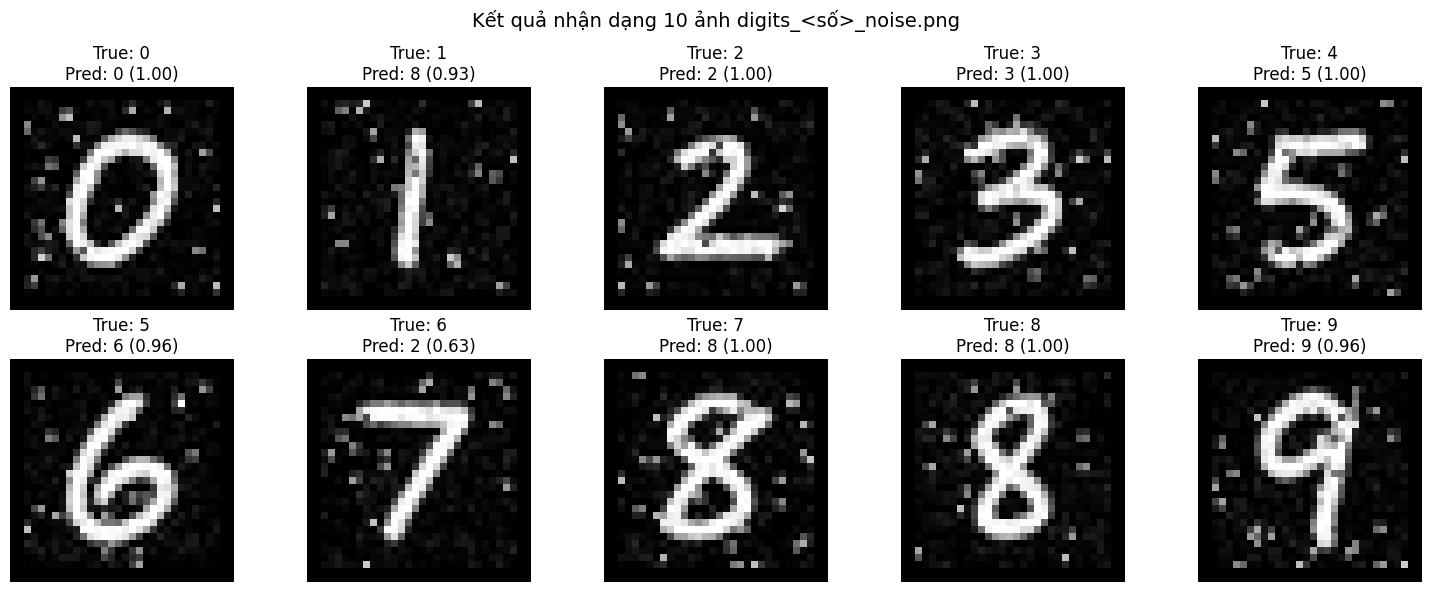


Độ chính xác trên 10 ảnh kiểm tra: 0.5000


In [ ]:
# ============================================================
# 10. Thử nhận dạng 10 ảnh nhiễu digits_0_noise.png ... digits_9_noise.png
# Chú ý:
# - Cần thay base_url cho đúng với thư mục chứa ảnh
# - Ảnh đầu vào sẽ được chuyển về đúng định dạng mà LeNet-5 đã học:
#   grayscale -> resize 28x28 -> normalize -> pad thành 32x32
# ============================================================

from urllib.request import urlopen
from PIL import Image
import io

# Ví dụ:
# base_url = "https://github.com/lthavnu/cv-book/raw/main/images"
# Nếu ảnh nằm trong thư mục con digits thì:
base_url = "https://github.com/lthavnu/cv-book/raw/main/images/digits"

def load_digit_image_from_url(image_url):
    """
    Đọc ảnh từ URL, chuyển về grayscale, resize 28x28,
    chuẩn hóa [0,1], rồi pad thành 32x32x1.
    """
    resp = urlopen(image_url)
    image_bytes = resp.read()

    I_pil = Image.open(io.BytesIO(image_bytes)).convert("L")   # grayscale
    I_pil = I_pil.resize((28, 28), Image.Resampling.LANCZOS)

    I = np.array(I_pil).astype("float32") / 255.0

    # Nếu ảnh có nền đen, chữ số trắng thì thường không cần đảo màu.
    # Nếu kết quả nhận dạng sai hàng loạt do ảnh có nền trắng, chữ số đen,
    # có thể bật dòng dưới đây để đảo màu:
    # I = 1.0 - I

    I = np.expand_dims(I, axis=-1)  # (28, 28, 1)
    I = np.pad(I, ((2, 2), (2, 2), (0, 0)), mode="constant")  # -> (32, 32, 1)
    return I

predicted_labels = []
true_labels = []

plt.figure(figsize=(15, 6))

for digit in range(10):
    image_url = f"{base_url}/digit_{digit}_noisy.png"

    try:
        I_test = load_digit_image_from_url(image_url)
        X_test_one = np.expand_dims(I_test, axis=0)  # (1, 32, 32, 1)

        y_prob = model.predict(X_test_one, verbose=0)[0]
        y_pred = int(np.argmax(y_prob))
        confidence = float(np.max(y_prob))

        predicted_labels.append(y_pred)
        true_labels.append(digit)

        plt.subplot(2, 5, digit + 1)
        plt.imshow(I_test[:, :, 0], cmap="gray")
        plt.title(f"True: {digit}\nPred: {y_pred} ({confidence:.2f})")
        plt.axis("off")

        print(f"digits_{digit}_noise.png -> dự đoán: {y_pred}, độ tin cậy: {confidence:.4f}")

    except Exception as e:
        plt.subplot(2, 5, digit + 1)
        plt.text(0.5, 0.5, f"Lỗi đọc ảnh\n{digit}", ha="center", va="center")
        plt.axis("off")
        print(f"Lỗi khi đọc {image_url}: {e}")

plt.suptitle("Kết quả nhận dạng 10 ảnh digits_<số>_noise.png", fontsize=14)
plt.tight_layout()
plt.show()

# Tính nhanh độ chính xác trên 10 ảnh thử nghiệm
if len(predicted_labels) == 10:
    acc_10 = np.mean(np.array(predicted_labels) == np.array(true_labels))
    print(f"\nĐộ chính xác trên 10 ảnh kiểm tra: {acc_10:.4f}")